# Importing Libraries

In [1]:
# to handle tabular data
import numpy as np
import pandas as pd

# visualize the data
import seaborn as sns 
import matplotlib.pyplot as plt

# Normalizing
from sklearn.preprocessing import RobustScaler,LabelEncoder

# balancing the data
from imblearn.over_sampling import SMOTE

# cross validation
from sklearn.model_selection import train_test_split

# Algorithms
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
# import systemcheck
import warnings
warnings.simplefilter("ignore")

# Data Acquisition

In [2]:
data = pd.read_csv("heart_2020_cleaned.csv")
data

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


# Data Analysis & Data Pre-Processing

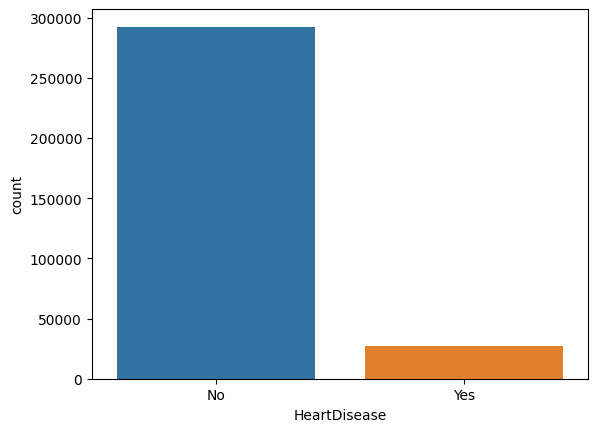

In [3]:
sns.countplot(data=data,x="HeartDisease")
plt.show()

In [4]:
data = data.sample(10000,random_state=0)
data.reset_index(drop=True,inplace=True)
data

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,23.44,No,No,No,10.0,20.0,Yes,Female,80 or older,White,No,No,Good,6.0,No,No,No
1,No,32.49,No,No,No,0.0,4.0,No,Male,40-44,White,No,Yes,Excellent,8.0,No,No,No
2,No,21.93,No,No,No,0.0,0.0,No,Male,60-64,White,No,Yes,Excellent,7.0,No,No,No
3,No,26.58,No,No,No,0.0,2.0,No,Male,45-49,White,No,Yes,Very good,7.0,No,No,No
4,No,19.02,Yes,No,No,2.0,2.0,No,Female,80 or older,White,No,Yes,Good,6.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,No,25.29,Yes,No,Yes,0.0,0.0,No,Female,80 or older,White,Yes,Yes,Very good,10.0,Yes,No,No
9996,No,35.48,No,No,No,0.0,0.0,No,Female,45-49,Black,No,Yes,Fair,7.0,No,No,No
9997,No,23.33,Yes,No,Yes,30.0,15.0,Yes,Female,60-64,American Indian/Alaskan Native,Yes,Yes,Poor,10.0,No,No,No
9998,No,28.84,Yes,No,Yes,0.0,30.0,Yes,Female,60-64,White,No,Yes,Good,4.0,Yes,No,No


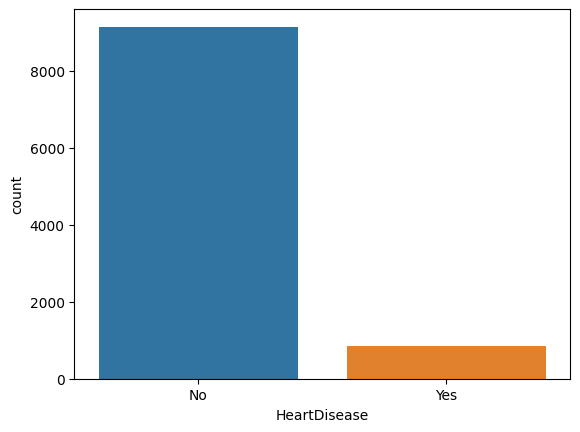

In [5]:
sns.countplot(data=data,x="HeartDisease")
plt.show()

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      10000 non-null  object 
 1   BMI               10000 non-null  float64
 2   Smoking           10000 non-null  object 
 3   AlcoholDrinking   10000 non-null  object 
 4   Stroke            10000 non-null  object 
 5   PhysicalHealth    10000 non-null  float64
 6   MentalHealth      10000 non-null  float64
 7   DiffWalking       10000 non-null  object 
 8   Sex               10000 non-null  object 
 9   AgeCategory       10000 non-null  object 
 10  Race              10000 non-null  object 
 11  Diabetic          10000 non-null  object 
 12  PhysicalActivity  10000 non-null  object 
 13  GenHealth         10000 non-null  object 
 14  SleepTime         10000 non-null  float64
 15  Asthma            10000 non-null  object 
 16  KidneyDisease     10000 non-null  object 

In [7]:
data.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,10000.000000,10000.00000,10000.000000,10000.000000
mean,28.335022,3.44220,3.836400,7.083500
std,6.301305,8.00574,7.926747,1.428542
min,12.880000,0.00000,0.000000,1.000000
25%,23.990000,0.00000,0.000000,6.000000
50%,27.360000,0.00000,0.000000,7.000000
75%,31.620000,2.00000,3.000000,8.000000
max,75.310000,30.00000,30.000000,24.000000


## checking missing values

In [8]:
dataframe = pd.concat([data.isna().sum().sort_values(ascending=False),data.isna().sum().sort_values(ascending=False)/len(data)*100],axis=1)

dataframe.columns = ["Missing values","% percentages"]
dataframe.style.background_gradient("Blues")

,Missing values,% percentages
HeartDisease,0,0.000000
BMI,0,0.000000
KidneyDisease,0,0.000000
Asthma,0,0.000000
SleepTime,0,0.000000
GenHealth,0,0.000000
PhysicalActivity,0,0.000000
Diabetic,0,0.000000
Race,0,0.000000
AgeCategory,0,0.000000


# Drop Duplicated rows

In [9]:
data[data.duplicated()].shape

(33, 18)

In [10]:
data[data.duplicated()]

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
1433,Yes,35.43,Yes,No,No,0.0,0.0,No,Female,70-74,White,Yes,Yes,Good,8.0,No,No,No
2193,No,27.12,No,No,No,0.0,0.0,No,Male,55-59,White,No,Yes,Excellent,7.0,No,No,No
2283,No,31.09,No,No,No,0.0,0.0,No,Female,65-69,White,No,Yes,Very good,7.0,No,No,No
2752,No,31.09,No,No,No,0.0,0.0,No,Female,65-69,White,No,Yes,Very good,7.0,No,No,No
3067,No,22.31,No,No,No,0.0,0.0,No,Female,60-64,White,No,Yes,Very good,8.0,No,No,No
3422,No,28.25,No,No,No,0.0,0.0,No,Female,65-69,White,No,Yes,Excellent,8.0,No,No,No
3832,No,30.13,No,No,No,0.0,0.0,No,Male,55-59,White,No,Yes,Very good,7.0,No,No,No
3960,No,25.75,No,No,No,0.0,0.0,No,Female,60-64,White,No,Yes,Excellent,8.0,No,No,No
3981,No,24.03,No,No,No,0.0,0.0,No,Female,55-59,White,No,Yes,Excellent,7.0,No,No,No
4426,No,24.41,No,No,No,0.0,0.0,No,Male,65-69,White,No,Yes,Excellent,7.0,No,No,No


In [11]:
data.drop_duplicates(inplace=True)
data.shape

(9967, 18)

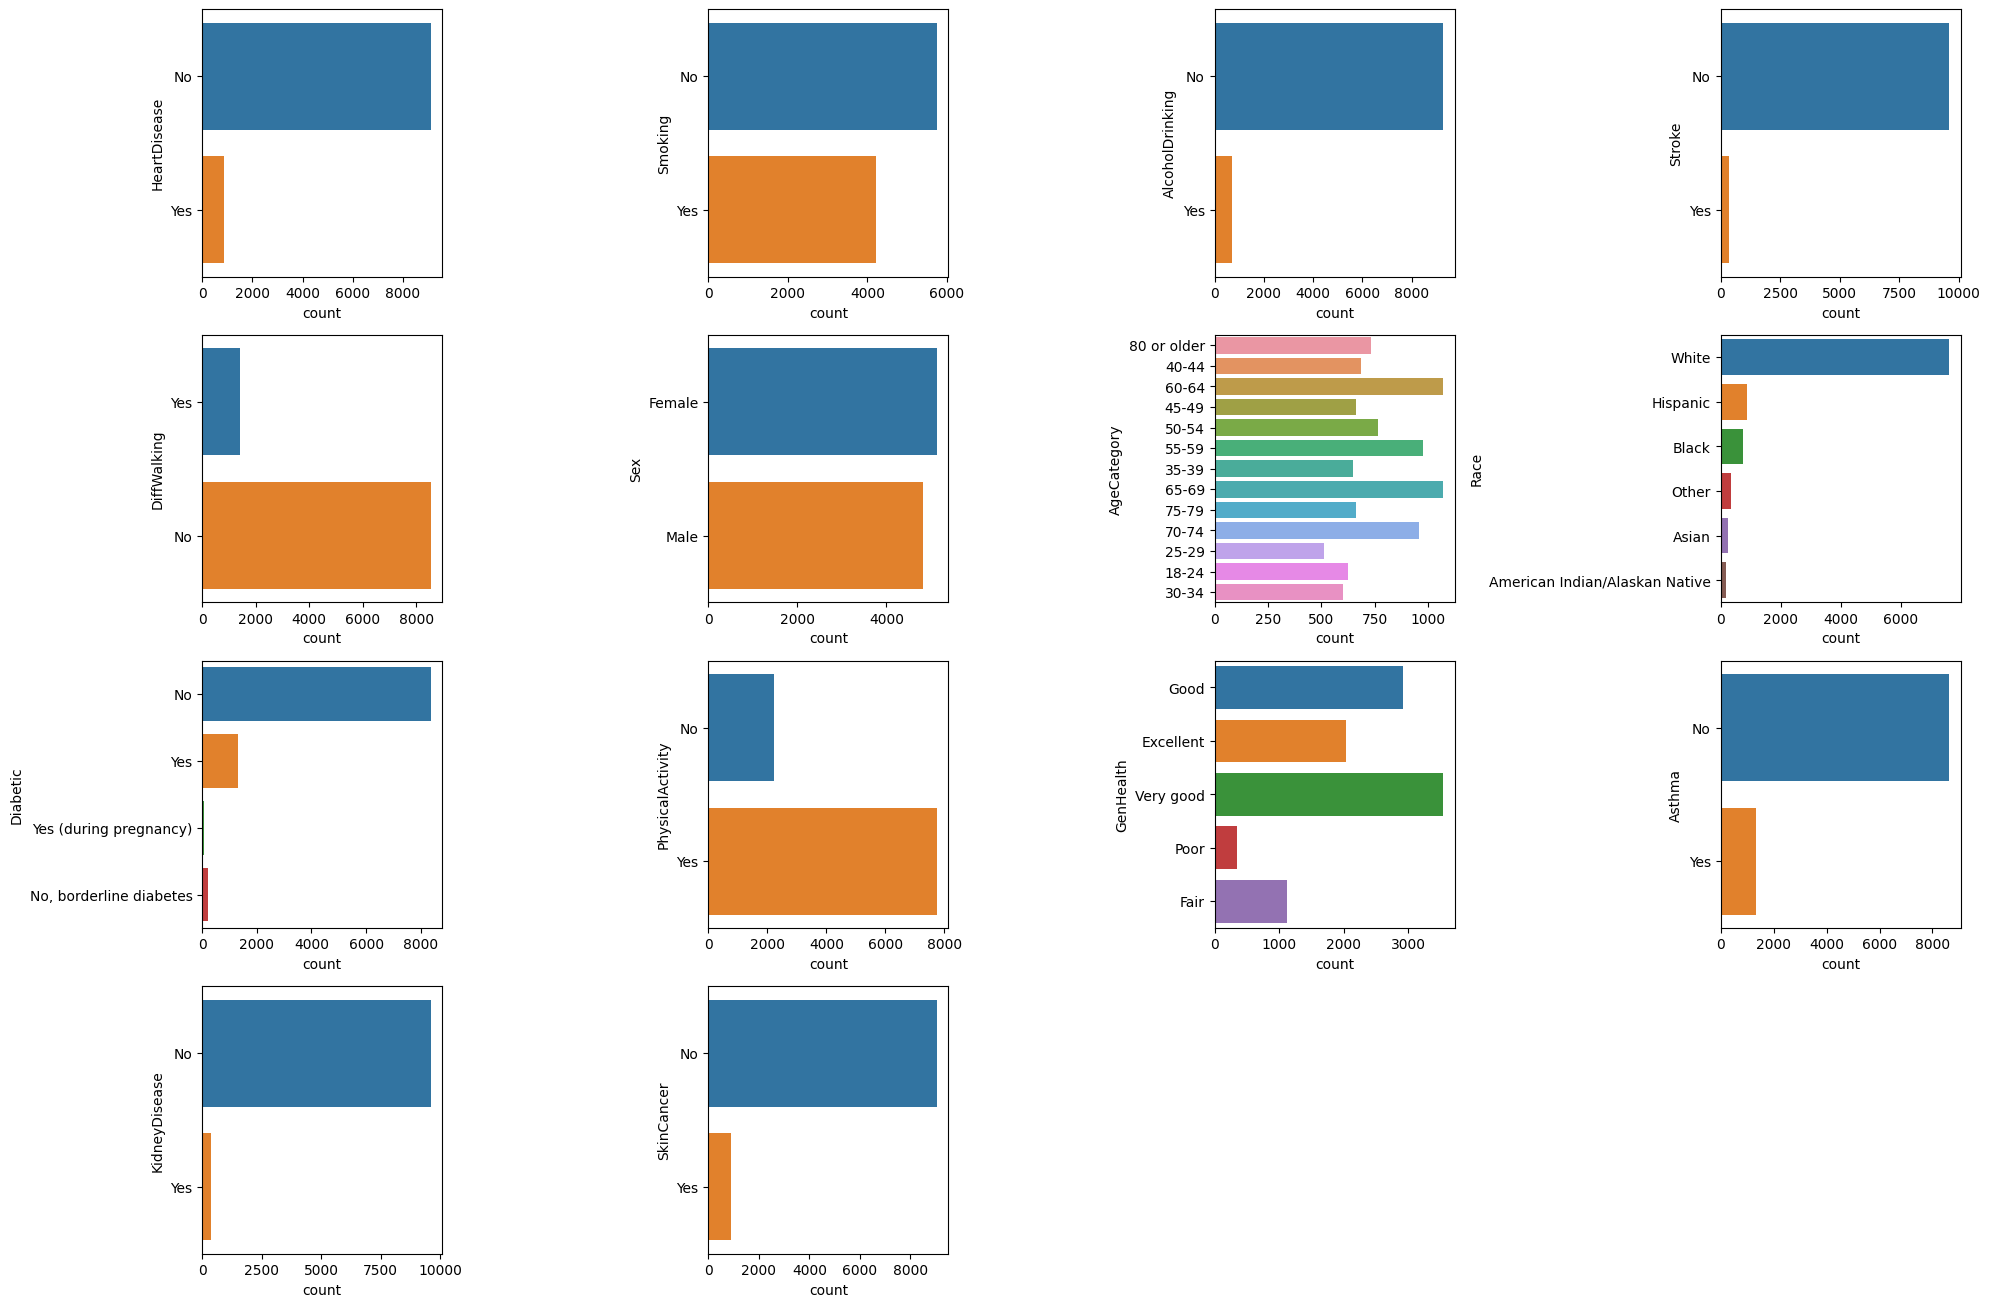

In [12]:
plt.figure(figsize=(20,16))
c = 1
for i in data.columns:
    if data[i].dtype == np.dtype("object"):
        plt.subplot(5,4,c)
        sns.countplot(data=data,y=i)
        c += 1
plt.tight_layout()
plt.show()

# Object type Data Encoding 

In [13]:
data_c = data.copy()
enc = dict()
for i in data.columns:
    if data_c[i].dtype == 'object':
        enc[i] = LabelEncoder()
        data_c[i] = enc[i].fit_transform(data_c[i])
data_c

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,23.44,0,0,0,10.0,20.0,1,0,12,5,0,0,2,6.0,0,0,0
1,0,32.49,0,0,0,0.0,4.0,0,1,4,5,0,1,0,8.0,0,0,0
2,0,21.93,0,0,0,0.0,0.0,0,1,8,5,0,1,0,7.0,0,0,0
3,0,26.58,0,0,0,0.0,2.0,0,1,5,5,0,1,4,7.0,0,0,0
4,0,19.02,1,0,0,2.0,2.0,0,0,12,5,0,1,2,6.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,25.29,1,0,1,0.0,0.0,0,0,12,5,2,1,4,10.0,1,0,0
9996,0,35.48,0,0,0,0.0,0.0,0,0,5,2,0,1,1,7.0,0,0,0
9997,0,23.33,1,0,1,30.0,15.0,1,0,8,0,2,1,3,10.0,0,0,0
9998,0,28.84,1,0,1,0.0,30.0,1,0,8,5,0,1,2,4.0,1,0,0


In [14]:
data_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9967 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      9967 non-null   int64  
 1   BMI               9967 non-null   float64
 2   Smoking           9967 non-null   int64  
 3   AlcoholDrinking   9967 non-null   int64  
 4   Stroke            9967 non-null   int64  
 5   PhysicalHealth    9967 non-null   float64
 6   MentalHealth      9967 non-null   float64
 7   DiffWalking       9967 non-null   int64  
 8   Sex               9967 non-null   int64  
 9   AgeCategory       9967 non-null   int64  
 10  Race              9967 non-null   int64  
 11  Diabetic          9967 non-null   int64  
 12  PhysicalActivity  9967 non-null   int64  
 13  GenHealth         9967 non-null   int64  
 14  SleepTime         9967 non-null   float64
 15  Asthma            9967 non-null   int64  
 16  KidneyDisease     9967 non-null   int64  
 17  

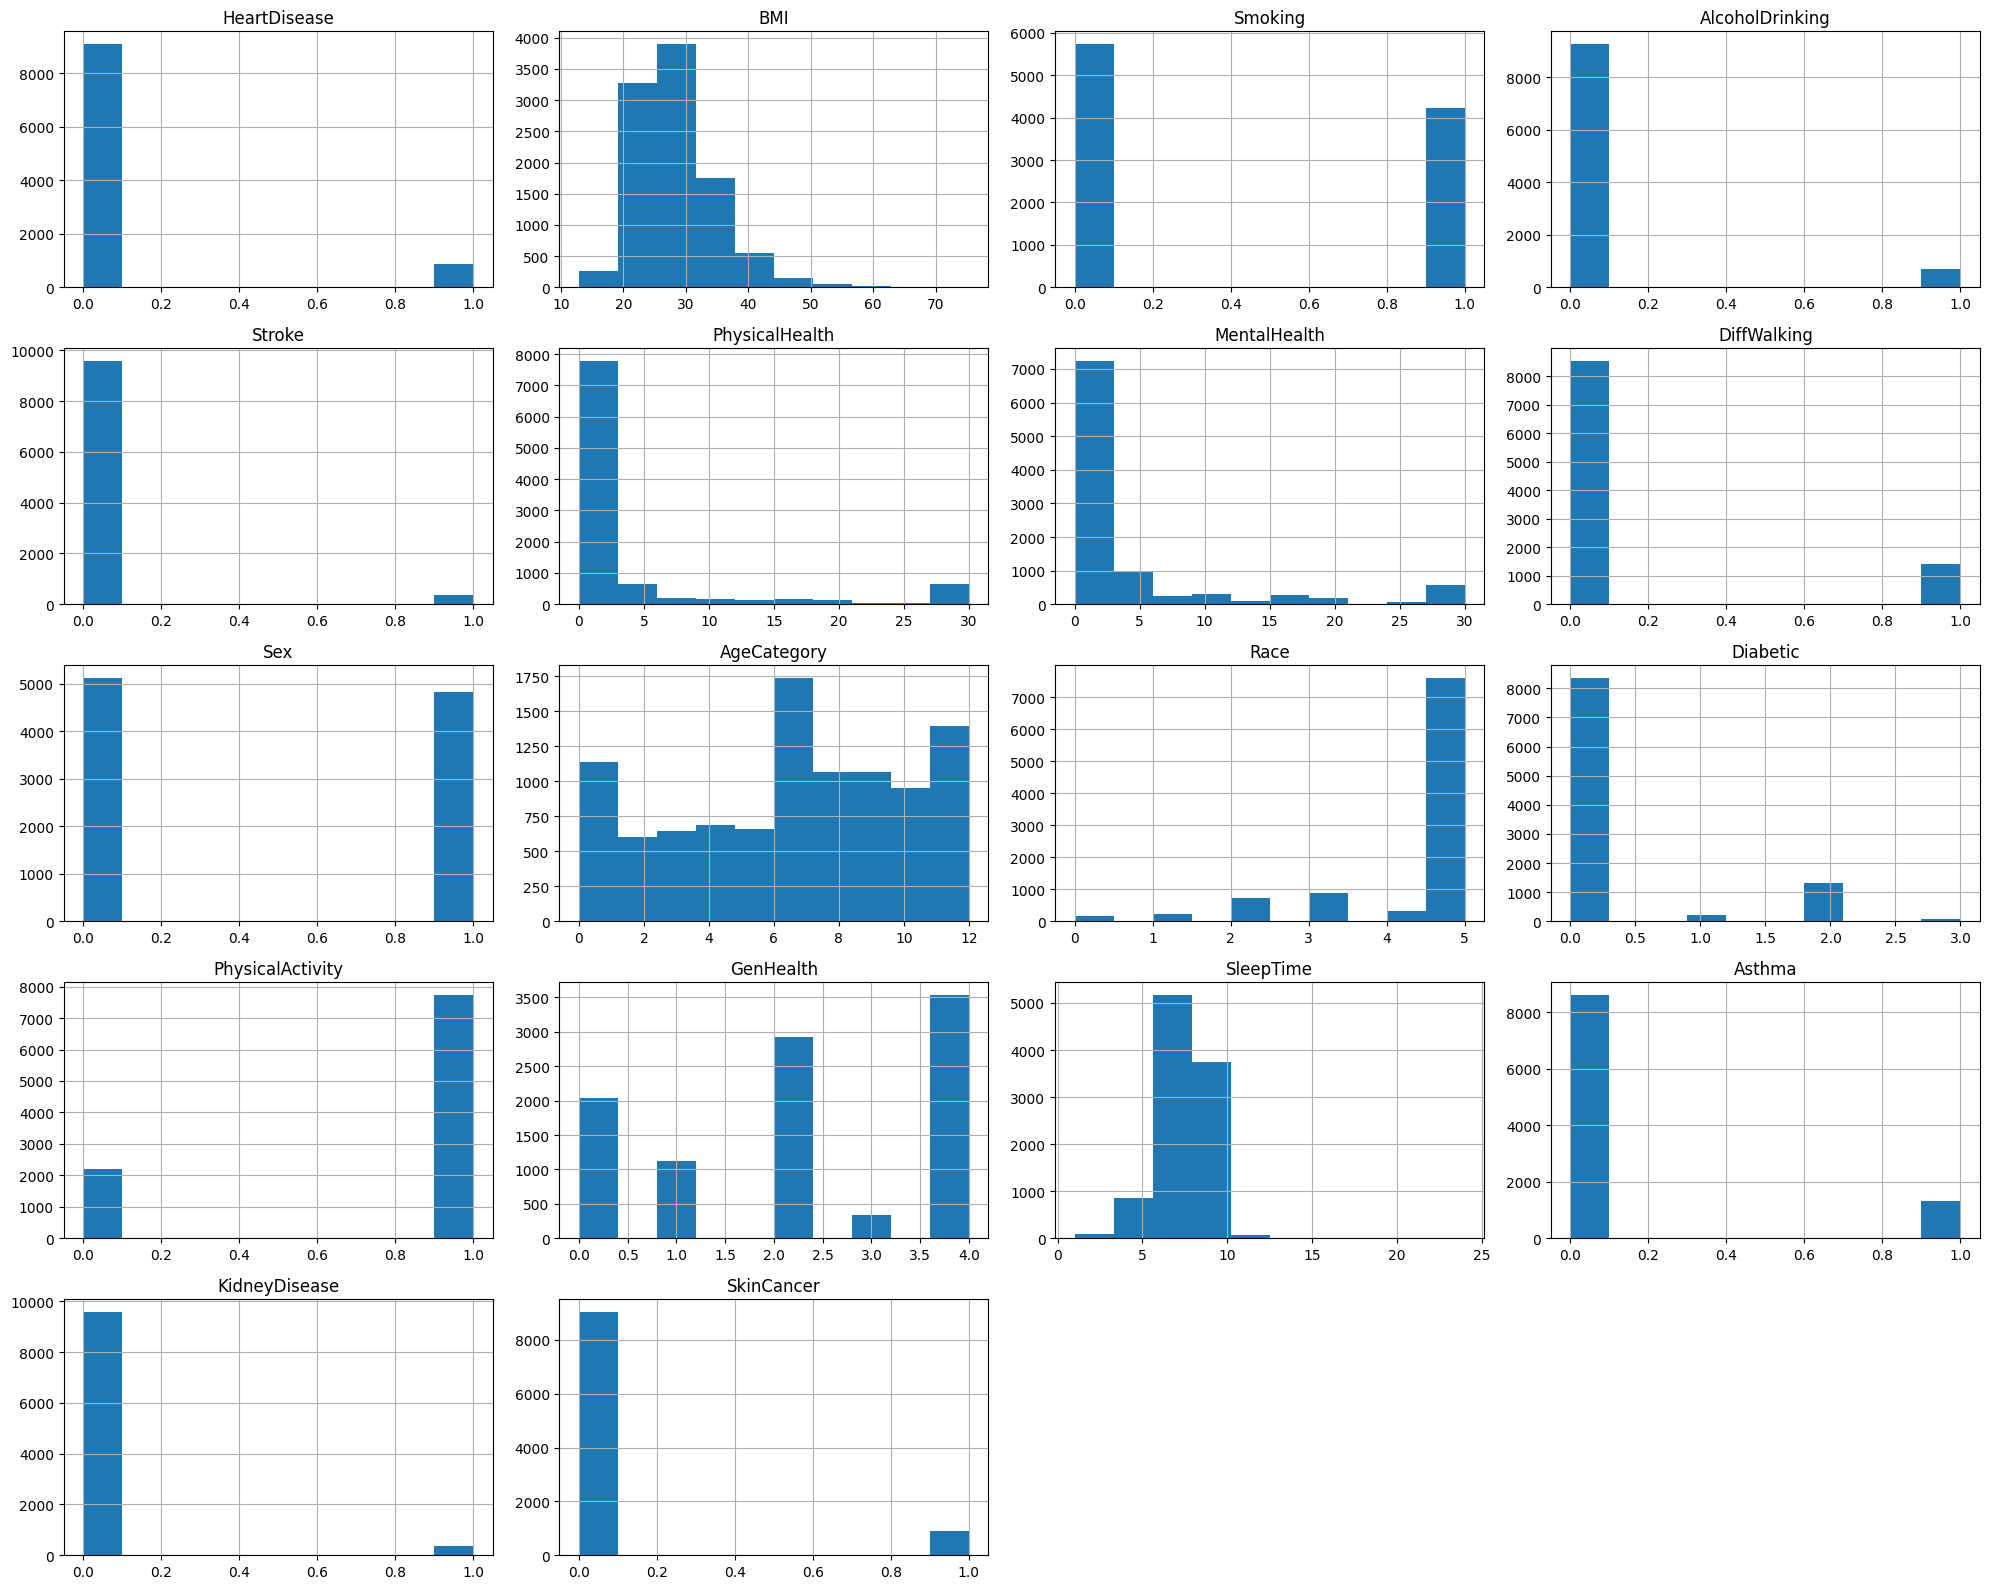

In [15]:
data_c.hist(figsize=(20,16))
plt.tight_layout()
plt.show()

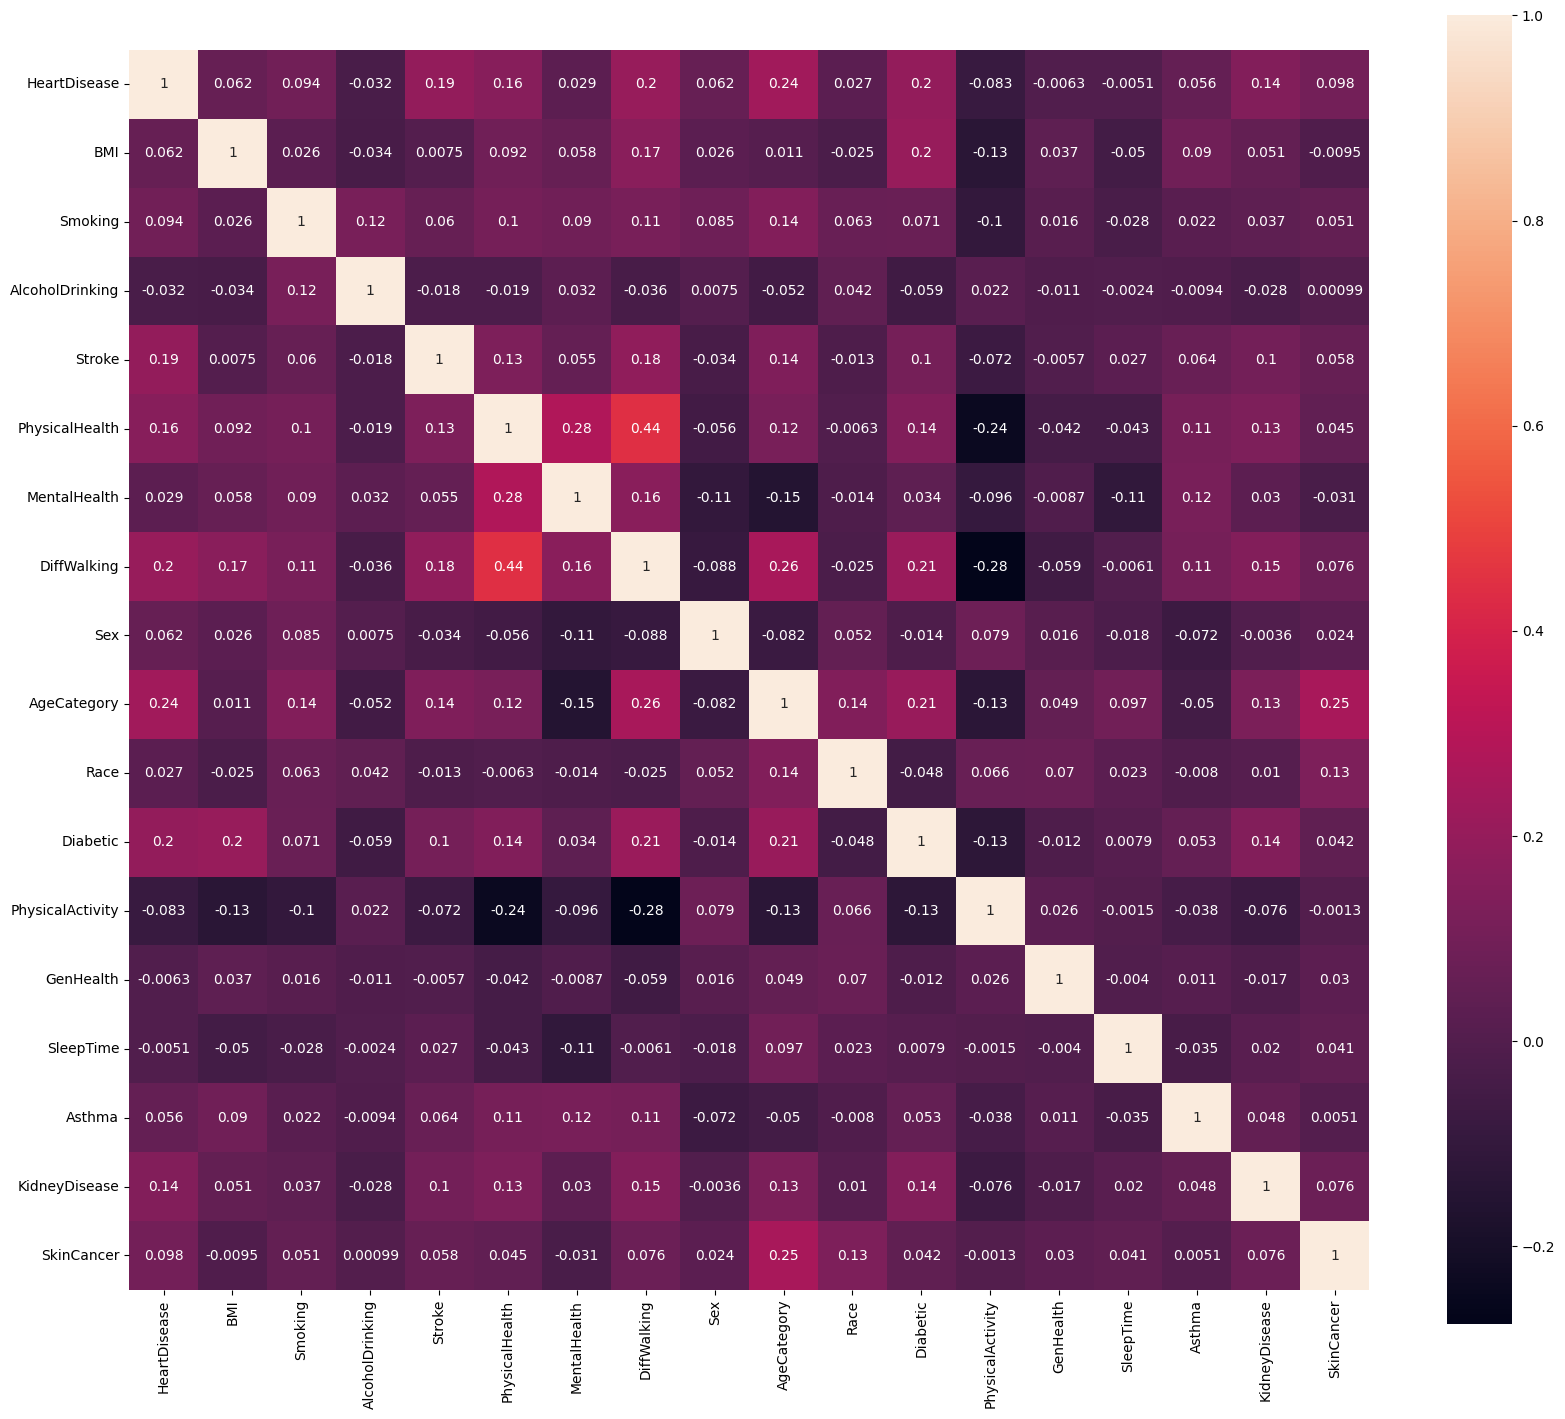

In [16]:
plt.figure(figsize = (20,17))
sns.heatmap(data_c.corr(),square=True,annot=True)
plt.show()

# Data Pre-Processing

# Understanding ML performance on complete data

In [17]:
from sklearn.metrics import f1_score

train_ip,test_ip,train_op,test_op = train_test_split(data_c.drop(columns=["HeartDisease"]),data_c["HeartDisease"],test_size=0.2,random_state=11)

rfr2 = RandomForestClassifier(class_weight="balanced_subsample",random_state=0)
rfr2.fit(train_ip,train_op)
y_pred = rfr2.predict(test_ip)
print('Accuracy performace with "complete data" :',accuracy_score(test_op,y_pred))

print('F1 score performace with "complete data" :',f1_score(test_op,y_pred))

Accuracy performace with "complete data" : 0.9167502507522568
F1 score performace with "complete data" : 0.08791208791208792


**********************************************

**********************************************

**********************************************

# Balancing the data

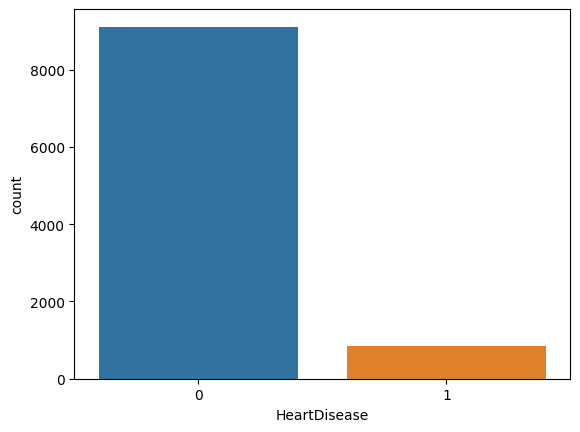

In [18]:
sns.countplot(data=data_c,x="HeartDisease")
plt.show()

<Axes: xlabel='HeartDisease', ylabel='count'>

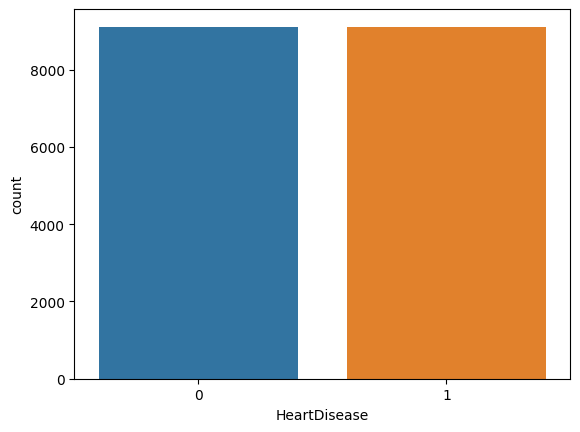

In [19]:
smote = SMOTE(random_state=0)
smote_X, smote_Y = smote.fit_resample(data_c.drop(columns=["HeartDisease"]), data_c["HeartDisease"])
sns.countplot(x=smote_Y)

# Normalizing the Balanced values of the Dataset

In [20]:
scale = RobustScaler()
scale.fit(smote_X)
X = scale.transform(smote_X)
X

array([[-0.54101527,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.60600628,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.73239676,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.25454365,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.8824449 ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.22778609,  0.        ,  0.        , ...,  1.        ,
         0.        ,  1.        ]])

# Data Partitioning

In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,smote_Y,test_size=0.2,random_state=11)

In [22]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape,)

(14574, 17) (3644, 17) (14574,) (3644,)


# Decision Tree Classifier

In [23]:
# instantiating the Algorithm
dtc = DecisionTreeClassifier(class_weight="balanced",random_state=6)

# Training the model
dtc.fit(X_train,y_train)

# Testing the model
y_pred = dtc.predict(X_test)    

## Evaluation

In [24]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred)*100,"%")

print('F1 score performace with "complete data" :',f1_score(y_test,y_pred))

Accuracy Score:  89.07793633369924 %
F1 score performace with "complete data" : 0.8924905456509995


In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1840
           1       0.87      0.92      0.89      1804

    accuracy                           0.89      3644
   macro avg       0.89      0.89      0.89      3644
weighted avg       0.89      0.89      0.89      3644



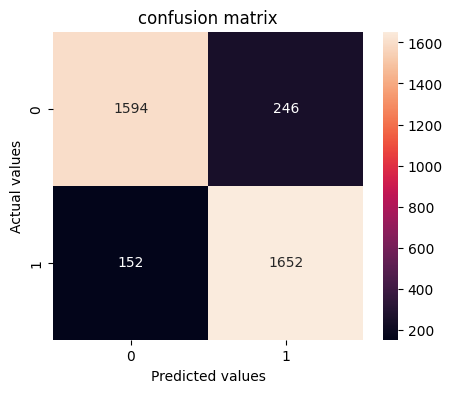

In [26]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

# RandomForestClassifier

In [27]:
# instantiating the Algorithm
rfc = RandomForestClassifier(class_weight="balanced_subsample",random_state=6)

# Training the model
rfc.fit(X_train,y_train)

# Testing the model
y_pred = rfc.predict(X_test)    

## Evaluation

In [28]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred)*100,"%")

print('F1 score performace with "complete data" :',f1_score(y_test,y_pred))

Accuracy Score:  93.33150384193193 %
F1 score performace with "complete data" : 0.9341998375304632


In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1840
           1       0.91      0.96      0.93      1804

    accuracy                           0.93      3644
   macro avg       0.93      0.93      0.93      3644
weighted avg       0.93      0.93      0.93      3644



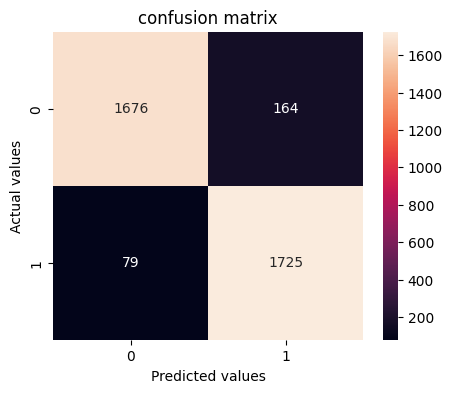

In [30]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

# SVM

In [31]:
# instantiating the Algorithm
svm = SVC(max_iter=5000,C=7,gamma=.1)

# Training the model
svm.fit(X_train,y_train)

# Testing the model
svm_pred = svm.predict(X_test)

## Evaluation

In [32]:
print("Accuracy Score: ",accuracy_score(y_test,svm_pred)*100,"%")

print('F1 score performace with "complete data" :',f1_score(y_test,y_pred))

Accuracy Score:  83.94621295279913 %
F1 score performace with "complete data" : 0.9341998375304632


In [33]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1840
           1       0.81      0.89      0.85      1804

    accuracy                           0.84      3644
   macro avg       0.84      0.84      0.84      3644
weighted avg       0.84      0.84      0.84      3644



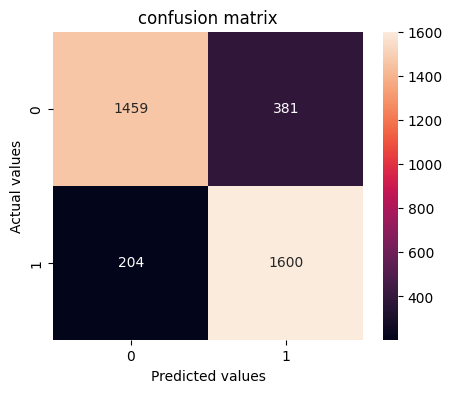

In [34]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,svm_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

# Passive Aggressive Classifier

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,smote_Y,test_size=0.2,random_state=3)
   
# instantiating the Algorithm
pac = PassiveAggressiveClassifier(class_weight="balanced",random_state=13)

# Training the model
pac.fit(X_train,y_train)

# Testing the model
pac_pred = pac.predict(X_test)

## Evaluation

In [36]:
print("Accuracy Score: ",accuracy_score(y_test,pac_pred)*100,"%")

Accuracy Score:  66.46542261251372 %


In [37]:
print(classification_report(y_test,pac_pred))

              precision    recall  f1-score   support

           0       0.71      0.55      0.62      1813
           1       0.64      0.77      0.70      1831

    accuracy                           0.66      3644
   macro avg       0.67      0.66      0.66      3644
weighted avg       0.67      0.66      0.66      3644



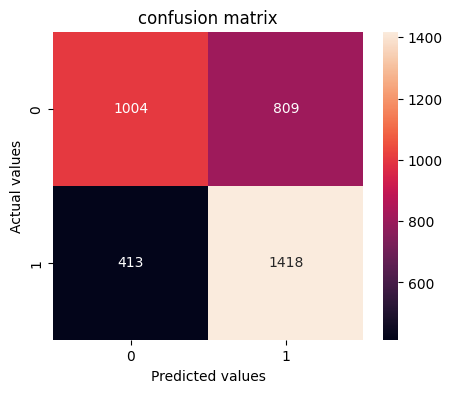

In [38]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,pac_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

## XG BOOST

In [39]:
# instantiating the Algorithm
xgb = XGBClassifier()

# Training the model
xgb.fit(X_train,y_train)

# Testing the model
y_pred = xgb.predict(X_test)   

## Evaluation

In [40]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred)*100,"%")

Accuracy Score:  90.69703622392976 %


In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1813
           1       0.92      0.90      0.91      1831

    accuracy                           0.91      3644
   macro avg       0.91      0.91      0.91      3644
weighted avg       0.91      0.91      0.91      3644



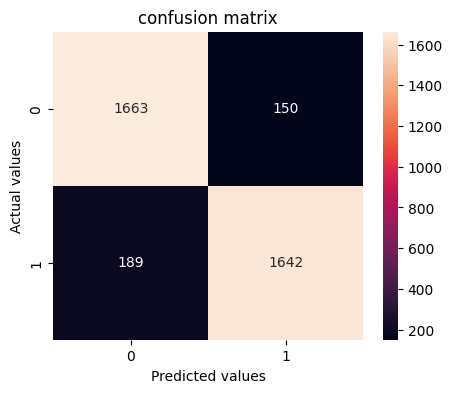

In [42]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()

## Logistic regression

In [43]:
# instantiating the Algorithm
lr = LogisticRegression()

# Training the model
lr.fit(X_train,y_train)

# Testing the model
y_pred = lr.predict(X_test)  

## Evaluation

In [44]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred)*100,"%")

Accuracy Score:  74.86278814489572 %


In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74      1813
           1       0.73      0.79      0.76      1831

    accuracy                           0.75      3644
   macro avg       0.75      0.75      0.75      3644
weighted avg       0.75      0.75      0.75      3644



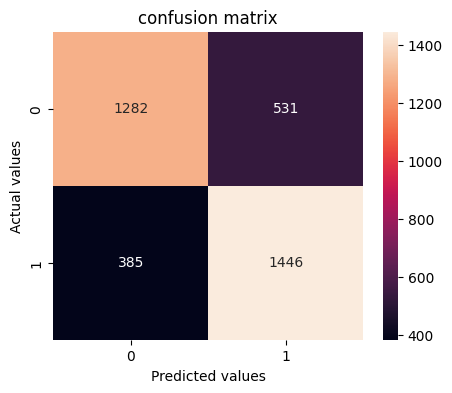

In [46]:
plt.figure(figsize=(5,4))
plt.title("confusion matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.show()